# Explainable Road Damage Detection using YOLOv8 and Grad-CAM

## Training Notebook

This notebook contains the complete workflow for training a custom YOLOv8 model for road damage detection. It includes dataset preparation, model training, evaluation, inference, and preparation for Grad-CAM explainability analysis.

**Project Status:** Training Pipeline

In [ ]:
# ============================================
# Install Required Libraries
# ============================================

!pip install -q ultralytics

print("✅ Ultralytics Installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.1 MB/s eta 0:00:00
✅ Ultralytics Installed


In [ ]:
# ============================================
# Import Libraries
# ============================================

from ultralytics import YOLO

import os
import yaml
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries Imported Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries Imported Successfully


# Step 4: Dataset Preparation

A custom road damage dataset is required because the pretrained YOLOv8 model is trained on the COCO dataset, which does not contain road damage classes such as potholes, longitudinal cracks, or transverse cracks.

The dataset used for training is organized in the YOLOv8 format, containing separate training, validation, and testing splits along with a configuration file (`data.yaml`).

In [ ]:
# ============================================
# Check GPU Availability
# ============================================

import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU : Tesla T4


In [ ]:
!pip install -q kaggle ultralytics

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"riyasoy","key":"d3027d493d89004adc44be5a9d7237ab"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ Kaggle configured successfully")

✅ Kaggle configured successfully


In [ ]:
!kaggle datasets list -s "rdd2022" | head -10



ref                                       title                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  -------------------------  -----------  --------------------------  -------------  ---------  ---------------  
aliabdelmenam/rdd-2022                    RDD 2022                   10632799923  2025-02-23 02:30:31.640000          10225         65  0.6875           
sreekaraditya/rdd2022-yolo-crackscan-v2   RDD2022 YOLO               13259447269  2026-05-16 12:12:18.200000            354          5  0.875            
juusos/rdd2022es                          RDD2022ES                   2611933018  2025-05-07 08:54:20.383000            604          6  0.875            
sujityp/rdd2022                           rdd2022                    11270234471  2024-04-08 13:20:14.960000            734          6  0.0625           
alaagaberh/augmented-rdd2022              Augmented RDD2022          1804359

In [ ]:
!kaggle datasets list -s "road damage yolo" | head -20

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes  Road Damage Dataset: Potholes, Cracks and Manholes    194168092  2026-02-10 15:26:14.110000           3655         34  0.875            
aliabdelmenam/rdd-2022                                           RDD 2022                                            10632799923  2025-02-23 02:30:31.640000          10225         65  0.6875           
muskanverma24/pothole-detection-dataset-yolov11-optimized        Pothole Detection Dataset: YOLOv11 Optimized          225825620  2026-01-04 13:08:56.893000            672          4  0.875   

In [ ]:
# ============================================
# Download Road Damage Dataset
# ============================================

!kaggle datasets download -d lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

Dataset URL: https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
License(s): MIT
100% 185M/185M [00:12<00:00, 15.7MB/s]



In [ ]:
# ============================================
# Verify Downloaded Dataset
# ============================================

import os

for file in os.listdir():
    if file.endswith(".zip"):
        print("ZIP File:", file)
        print("Size (MB):", round(os.path.getsize(file) / (1024*1024), 2))

ZIP File: road-damage-dataset-potholes-cracks-and-manholes.zip
Size (MB): 185.17


In [ ]:
# ============================================
# Extract Dataset
# ============================================

import zipfile

zip_file = "road-damage-dataset-potholes-cracks-and-manholes.zip"
extract_path = "RoadDamageDataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
# ============================================
# Inspect Dataset Structure
# ============================================

from pathlib import Path

dataset_path = Path("RoadDamageDataset")

for path in sorted(dataset_path.rglob("*")):
    if path.is_dir():
        print(path)

RoadDamageDataset/data
RoadDamageDataset/data/images
RoadDamageDataset/data/labels
RoadDamageDataset/data/labels-YOLO


In [ ]:
# ============================================
# Inspect Images Folder
# ============================================

from pathlib import Path

image_path = Path("RoadDamageDataset/data/images")

print("Number of images:", len(list(image_path.glob("*"))))

print("\nFirst 10 images:")

for img in list(image_path.glob("*"))[:10]:
    print(img.name)

Number of images: 2009

First 10 images:
vlcsnap-2025-02-19-17h05m28s575.jpg
vlcsnap-2025-02-19-15h07m53s295.jpg
vlcsnap-2025-02-18-18h42m21s488.jpg
vlcsnap-2025-02-26-20h37m58s129.jpg
vlcsnap-2025-02-19-14h19m29s310.jpg
vlcsnap-2025-02-18-18h31m05s922.jpg
20250223_144843.jpg
vlcsnap-2025-02-26-20h35m23s844.jpg
vlcsnap-2025-02-19-14h21m34s505.jpg
vlcsnap-2025-02-19-14h10m47s605.jpg


In [ ]:
# ============================================
# Inspect YOLO Labels
# ============================================

label_path = Path("RoadDamageDataset/data/labels-YOLO")

labels = list(label_path.glob("*.txt"))

print("Number of label files:", len(labels))

print("\nExample Label File:")

with open(labels[0]) as f:
    print(f.read())

Number of label files: 2009

Example Label File:
1 0.489062 0.650000 0.034375 0.294444


In [ ]:
# ============================================
# Split Dataset into Train / Validation / Test
# ============================================

import os
import shutil
import random
from pathlib import Path

random.seed(42)

base = Path("RoadDamageDataset/data")

images = sorted((base / "images").glob("*"))
labels = base / "labels-YOLO"

dataset = Path("dataset")

for split in ["train", "valid", "test"]:
    (dataset / split / "images").mkdir(parents=True, exist_ok=True)
    (dataset / split / "labels").mkdir(parents=True, exist_ok=True)

random.shuffle(images)

n = len(images)

train = images[:int(0.7*n)]
valid = images[int(0.7*n):int(0.85*n)]
test = images[int(0.85*n):]

splits = {
    "train": train,
    "valid": valid,
    "test": test
}

for split_name, split_images in splits.items():

    for img in split_images:

        shutil.copy(img, dataset/split_name/"images"/img.name)

        label = labels/(img.stem + ".txt")

        if label.exists():
            shutil.copy(label, dataset/split_name/"labels"/label.name)

print("✅ Dataset Split Completed")

✅ Dataset Split Completed


In [ ]:
# ============================================
# Verify Dataset Split
# ============================================

from pathlib import Path

dataset = Path("dataset")

for split in ["train", "valid", "test"]:

    img_count = len(list((dataset/split/"images").glob("*")))
    lbl_count = len(list((dataset/split/"labels").glob("*.txt")))

    print(f"{split.upper():6} Images: {img_count}")
    print(f"       Labels: {lbl_count}")
    print("-"*35)

TRAIN  Images: 1406
       Labels: 1406
-----------------------------------
VALID  Images: 301
       Labels: 301
-----------------------------------
TEST   Images: 302
       Labels: 302
-----------------------------------


In [ ]:
# ============================================
# Create data.yaml for YOLOv8
# ============================================

import yaml

data_yaml = {
    "path": "/content/dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 3,
    "names": [
        "crack",
        "manhole",
        "pothole"
    ]
}

with open("dataset/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("✅ data.yaml created successfully!")

✅ data.yaml created successfully!


In [ ]:
# ============================================
# Verify data.yaml
# ============================================

with open("dataset/data.yaml") as f:
    print(f.read())

path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- crack
- manhole
- pothole



In [ ]:
# ============================================
# Check Unique Class IDs
# ============================================

from pathlib import Path

label_folder = Path("RoadDamageDataset/data/labels-YOLO")

class_ids = set()

for txt_file in label_folder.glob("*.txt"):
    with open(txt_file, "r") as f:
        for line in f:
            if line.strip():
                class_ids.add(int(line.split()[0]))

print("Unique Class IDs:", sorted(class_ids))

Unique Class IDs: [0, 1, 2]


In [ ]:
# ============================================
# Train YOLOv8 Model
# ============================================

from ultralytics import YOLO

# Load pretrained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data="dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="RoadDamage_Training",
    name="yolov8n_road_damage",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_road_damage, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

In [48]:
import os

model_path = "/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt"

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size (MB):", round(os.path.getsize(model_path)/(1024*1024), 2))

Exists: True
Size (MB): 5.94


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

results = model.predict(
    source="/content/dataset/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)

print("Predictions completed!")


image 1/302 /content/dataset/test/images/20250216_164521.jpg: 384x640 2 cracks, 2 manholes, 38.9ms
image 2/302 /content/dataset/test/images/20250219_164746.jpg: 384x640 3 manholes, 1 pothole, 6.4ms
image 3/302 /content/dataset/test/images/20250219_164838.jpg: 384x640 3 manholes, 2 potholes, 8.5ms
image 4/302 /content/dataset/test/images/20250219_164848.jpg: 384x640 (no detections), 5.8ms
image 5/302 /content/dataset/test/images/20250219_165056.jpg: 384x640 1 crack, 5.5ms
image 6/302 /content/dataset/test/images/20250219_165753.jpg: 384x640 1 crack, 5.5ms
image 7/302 /content/dataset/test/images/20250219_170258.jpg: 384x640 2 cracks, 2 manholes, 6.2ms
image 8/302 /content/dataset/test/images/20250219_170531.jpg: 384x640 1 crack, 5.9ms
image 9/302 /content/dataset/test/images/20250219_170556.jpg: 384x640 3 cracks, 5.6ms
image 10/302 /content/dataset/test/images/20250219_170909.jpg: 384x640 1 crack, 5.7ms
image 11/302 /content/dataset/test/images/20250223_104743.jpg: 384x640 4 cracks, 1 

In [ ]:
import glob

folders = glob.glob("/content/runs/detect/predict*")

print(folders)

['/content/runs/detect/predict']


In [ ]:
import shutil
import glob
import os

pred_folder = "/content/runs/detect/predict"   # we'll change this if needed

os.makedirs("/content/project_results/predictions", exist_ok=True)

for img in glob.glob(pred_folder + "/*.jpg"):
    shutil.copy(img, "/content/project_results/predictions")

print("Copied:", len(glob.glob("/content/project_results/predictions/*.jpg")))

Copied: 302


In [ ]:
import shutil

shutil.make_archive(
    "/content/road_damage_project_results",
    "zip",
    "/content/project_results"
)

print("ZIP created successfully!")

ZIP created successfully!


In [ ]:
import os

prediction_folder = "/content/runs/detect/predict"

print("Number of predicted images:",
      len(os.listdir(prediction_folder)))

Number of predicted images: 302


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

prediction_folder = Path("/content/runs/detect/predict-2")

images = sorted(prediction_folder.glob("*.jpg"))

for img_path in images[:5]:
    plt.figure(figsize=(8,6))
    plt.imshow(Image.open(img_path))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [ ]:
# ============================================
# Evaluate the Trained YOLOv8 Model
# ============================================

from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

metrics = model.val()

print(metrics)

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3338.6±880.0 MB/s, size: 96.1 KB)
val: Scanning /content/dataset/valid/labels.cache... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 126.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.7it/s 3.3s
                   all        301        725      0.497      0.475      0.442      0.193
                 crack        120        205      0.409      0.429      0.361      0.149
               manhole        205        372      0.388      0.368      0.309      0.118
               pothole        113        148      0.693      0.628      0.657      0.313
Speed: 1.2ms preprocess, 2.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.

In [ ]:
# ============================================
# Show Training Result Files
# ============================================

from pathlib import Path

results_dir = Path("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage")

print("Files generated during training:\n")

for file in sorted(results_dir.iterdir()):
    print(file.name)

Files generated during training:

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch1760.jpg
train_batch1761.jpg
train_batch1762.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


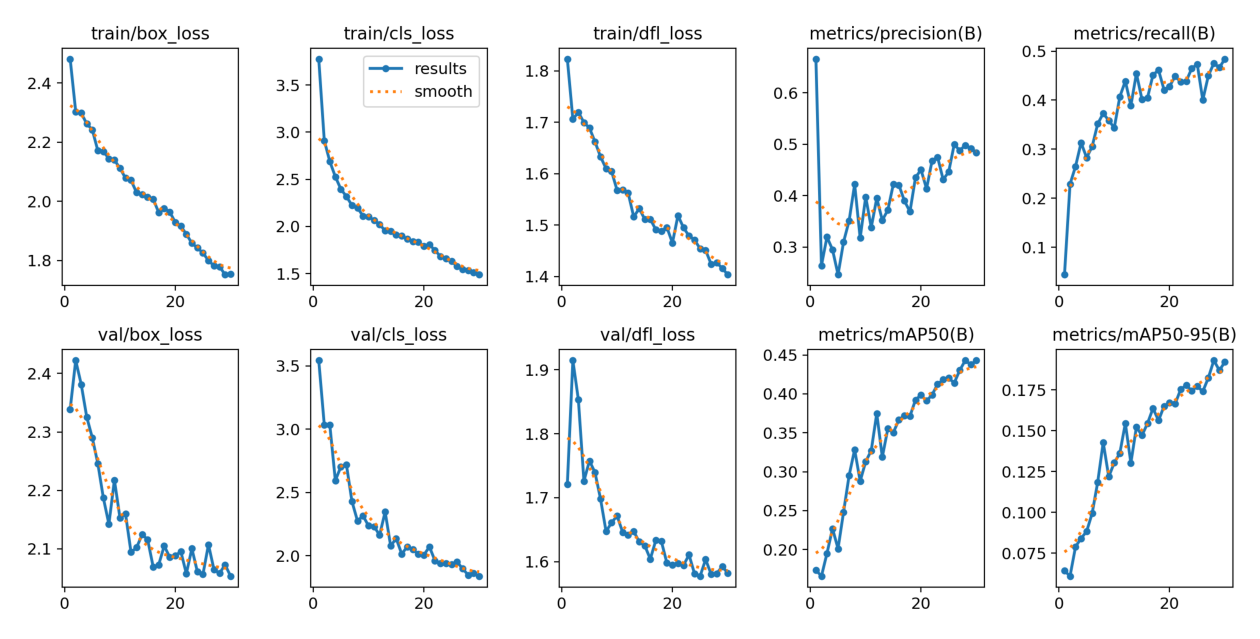

In [ ]:
# ============================================
# Display Training Results
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/results.png")

plt.figure(figsize=(16,10))
plt.imshow(img)
plt.axis("off")
plt.show()

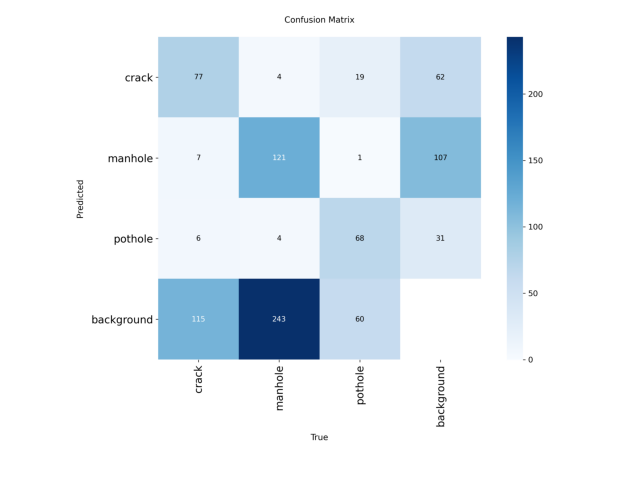

In [ ]:
# ============================================
# Display Confusion Matrix
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

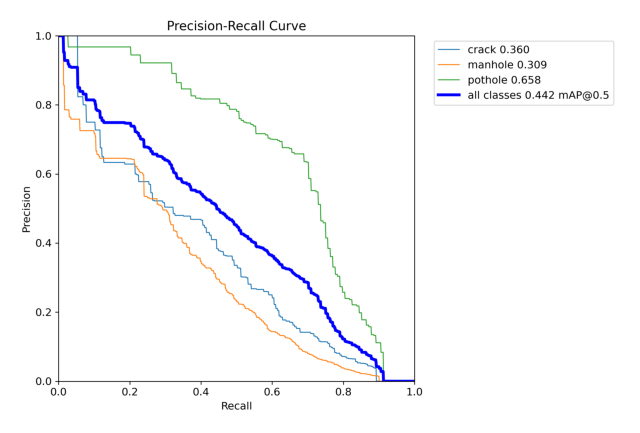

In [ ]:
# ============================================
# Display Precision-Recall Curve
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/BoxPR_curve.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 116.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=33c0a97a3f92a1250d83942c18f73f81294dbf0011b52a6593cb77ca6b6dc99c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

print(len(model.model.model))

23


In [ ]:
for i, layer in enumerate(model.model.model):
    print(i, ":", layer.__class__.__name__)

0 : Conv
1 : Conv
2 : C2f
3 : Conv
4 : C2f
5 : Conv
6 : C2f
7 : Conv
8 : C2f
9 : SPPF
10 : Upsample
11 : Concat
12 : C2f
13 : Upsample
14 : Concat
15 : C2f
16 : Conv
17 : Concat
18 : C2f
19 : Conv
20 : Concat
21 : C2f
22 : Detect


In [ ]:
from google.colab import files
import shutil

# Zip the training results
shutil.make_archive(
    "/content/RoadDamage_Project_Results",
    "zip",
    "/content/runs/detect/RoadDamage_Training/yolov8n_road_damage"
)

print("✅ ZIP created!")

✅ ZIP created!


In [ ]:
files.download("/content/RoadDamage_Project_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

folders = [
    "/content/project_results",
    "/content/project_results/figures",
    "/content/project_results/predictions"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
import shutil

source = "/content/runs/detect/RoadDamage_Training/yolov8n_road_damage"

files = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for f in files:
    shutil.copy(
        f"{source}/{f}",
        f"/content/project_results/figures/{f}"
    )

print("Figures copied successfully.")

Figures copied successfully.


In [ ]:
import shutil
import glob

pred_folder = "/content/runs/detect/predict-2"

images = glob.glob(pred_folder + "/*.jpg")

print("Predicted Images:", len(images))

for img in images[:10]:
    shutil.copy(img, "/content/project_results/predictions/")

Predicted Images: 0


In [ ]:
import shutil

shutil.make_archive(
    "/content/road_damage_project_results",
    "zip",
    "/content/project_results"
)

print("ZIP created.")

ZIP created.


In [ ]:
import os

pred_folder = "/content/runs/detect/predict-2"

print("Exists:", os.path.exists(pred_folder))

if os.path.exists(pred_folder):
    files = os.listdir(pred_folder)
    print("Number of files:", len(files))
    print(files[:10])

Exists: False


In [ ]:
import os

print(os.listdir("/content/project_results"))
print()

print("Figures:")
print(os.listdir("/content/project_results/figures"))

print()

print("Predictions:")
print(os.listdir("/content/project_results/predictions"))

['figures', 'predictions']

Figures:
['results.png', 'confusion_matrix.png', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'BoxP_curve.png', 'BoxR_curve.png', 'BoxF1_curve.png']

Predictions:
['vlcsnap-2025-02-19-14h19m29s310.jpg', 'vlcsnap-2025-02-19-14h13m50s269.jpg', 'vlcsnap-00147.jpg', 'vlcsnap-2025-02-18-18h33m15s549.jpg', 'vlcsnap-2025-02-19-17h08m40s964.jpg', 'vlcsnap-2025-02-19-17h00m19s245.jpg', 'vlcsnap-2025-02-19-14h53m03s993.jpg', 'vlcsnap-2025-02-18-18h36m01s579.jpg', 'vlcsnap-2025-02-19-14h21m40s743.jpg', 'vlcsnap_2025-03-16-15h28m07s931.jpg', 'vlcsnap-2025-02-18-23h18m48s132.jpg', 'vlcsnap_2025-03-16-15h26m47s658.jpg', 'vlcsnap-2025-02-19-13h55m59s825.jpg', 'vlcsnap-2025-02-19-15h07m34s342.jpg', 'vlcsnap-2025-02-19-15h10m06s856.jpg', 'vlcsnap_2025-03-16-15h25m46s232.jpg', 'vlcsnap-2025-02-19-14h42m07s301.jpg', 'vlcsnap-2025-02-18-23h14m34s881.jpg', 'vlcsnap-2025-02-19-14h17m05s509.jpg', 'vlcsnap-2025-02-26-20h41m02s345.jpg', 'vlcsnap-2025-02-19-13h55m14s182.jpg'

In [ ]:
!pip install ultralytics grad-cam -q

In [ ]:

from ultralytics import YOLO

model = YOLO("/content/runs/detect/RoadDamage_Training/yolov8n_road_damage/weights/best.pt")

for i, layer in enumerate(model.model.model):
    print(i, ":", layer.__class__.__name__)

0 : Conv
1 : Conv
2 : C2f
3 : Conv
4 : C2f
5 : Conv
6 : C2f
7 : Conv
8 : C2f
9 : SPPF
10 : Upsample
11 : Concat
12 : C2f
13 : Upsample
14 : Concat
15 : C2f
16 : Conv
17 : Concat
18 : C2f
19 : Conv
20 : Concat
21 : C2f
22 : Detect


In [ ]:
target_layer = model.model.model[21]

print(target_layer)

C2f(
  (cv1): Conv(
    (conv): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    )
  )
)
